# Day 4 — t-SNE & Anomaly Detection

After learning clustering and PCA, today I focused on visualizing high-dimensional data with t-SNE and understanding how to find unusual data points using anomaly detection.

The main idea is that t-SNE helps me see local patterns and possible clusters, while anomaly detection helps me identify points that are different from the normal data.

# 1. t-SNE for Visualization

t-SNE (t-distributed Stochastic Neighbor Embedding) is a dimensionality-reduction technique mainly used for visualization.

Unlike PCA, which focuses on preserving global variance, t-SNE focuses more on keeping nearby points close to each other.

This makes it useful when I want to visually discover groups or patterns in high-dimensional data.

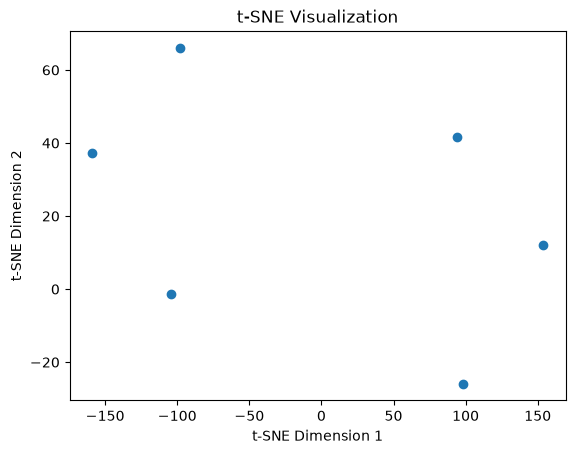

In [1]:
#Practical Example

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Example data with several features.
# t-SNE will reduce these features into 2 dimensions.
X = np.array([
    [1.0, 1.2, 0.9, 1.1],
    [1.2, 1.0, 1.1, 0.8],
    [1.1, 1.3, 1.0, 1.2],

    [5.0, 5.2, 4.9, 5.1],
    [5.2, 4.9, 5.1, 5.0],
    [4.8, 5.1, 5.0, 5.2]
])

# Reduce the original features to 2 dimensions
# so they can be visualized in a scatter plot.
tsne = TSNE(
    n_components=2,
    perplexity=3,#for small datasets, a lower perplexity value (e.g., 5-50) is often recommended. For larger datasets, a higher perplexity value (e.g., 30-100) may be more appropriate.
    learning_rate=200, 
)

X_tsne = tsne.fit_transform(X)

# Plot the new 2D representation.
plt.scatter(X_tsne[:, 0], X_tsne[:, 1])

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization")

plt.show()

# What I should understand

The original data has multiple features, but t-SNE gives me only two dimensions that I can plot.

The important point is that t-SNE is mainly for visualization. Its axes do not have a direct meaning like normal features, so I should not treat the two dimensions as meaningful model features.

# 2. PCA vs. t-SNE

I also learned that PCA and t-SNE can both reduce dimensions, but they have different purposes.

| PCA                          | t-SNE                                       |
| ---------------------------- | ------------------------------------------- |
| Preserves global variance    | Focuses on local neighborhoods              |
| Can be used for compression  | Mainly used for visualization               |
| Faster                       | Usually slower                              |
| Components have some meaning | Axes do not have meaningful interpretations |

- So, I can think about them like this:
PCA helps simplify the data, while t-SNE helps me see the structure of the data.

In [2]:
#Practical Example
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Scale the original features before working with them.
X_scaled = StandardScaler().fit_transform(X)

# PCA reduces the data while keeping important variance.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE creates a 2D representation mainly for visualization.
tsne = TSNE(
    n_components=2,
    perplexity=3,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)
print("t-SNE shape:", X_tsne.shape)

PCA shape: (6, 2)
t-SNE shape: (6, 2)


- The two methods can both give me a 2D dataset, but they are trying to preserve different types of structure.

# 3. What Is Anomaly Detection?

Anomaly detection means finding data points that are significantly different from what is considered normal.

Examples could include:

An unusual transaction in fraud detection.
A defective product in manufacturing.
An unusual system failure.
An incorrect or unexpected data point.

Anomaly detection is often treated as an unsupervised learning problem because unusual points are usually rare and do not have predefined labels.

- The basic idea is:
Learn what normal data looks like, then identify points that behave differently.

# 4. Isolation Forest

Isolation Forest is one of the algorithms I learned for anomaly detection.

Its main idea is that unusual points are easier to isolate than normal points because they are usually far away from the main group of data.

The algorithm repeatedly splits the data randomly. If a point can be isolated using only a few splits, it is more likely to be an anomaly.

In [3]:
# Practical Example

import numpy as np
from sklearn.ensemble import IsolationForest

# Most points are around the normal range.
# The last two points are much farther away,
# so they may be detected as anomalies.
X = np.array([
    [10, 11],
    [11, 10],
    [10, 12],
    [12, 11],
    [11, 12],
    [10, 10],

    [50, 50],
    [60, 5]
])

# contamination is my estimate of how much of the data
# may contain anomalies.
model = IsolationForest(
    contamination=0.25, # 25% of the data may be anomalies
    random_state=42
)

predictions = model.fit_predict(X)

print(predictions)

[ 1  1  1  1  1  1 -1 -1]


- Isolation Forest returns:

        - Normal point  → 1
        - Anomaly  → -1

- So I can use the predictions to find the unusual points.

In [4]:
# Select only the points classified as anomalies.
anomalies = X[predictions == -1]

print("Detected anomalies:")
print(anomalies)

Detected anomalies:
[[50 50]
 [60  5]]


- What I should understand

    The important thing is not just getting -1 from the model.

    I should understand that Isolation Forest is trying to identify points that are **easier to isolate from the rest of the dataset.**

# 5. The Contamination Parameter

The contamination parameter represents my estimate of the percentage of anomalies in the dataset.



In [5]:
# For example:
IsolationForest(contamination=0.05)


,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False


- means I am estimating that around 5% of the data may be anomalous.

- Choosing this value affects how many points the model will flag as anomalies.

In [7]:
# Practical Example

from sklearn.ensemble import IsolationForest

# I expect around 10% of the data to be unusual.
model = IsolationForest(
    contamination=0.10,
    random_state=42
)

predictions = model.fit_predict(X)

# Count how many points were detected as anomalies.
number_of_anomalies = sum(predictions == -1)

print("Number of anomalies:", number_of_anomalies)

Number of anomalies: 1


- The main thing I learned here is that contamination is not the algorithm discovering the true percentage automatically. It is an estimate I provide about how much anomalous data I expect.

# 6. How Clustering and Anomaly Detection Can Overlap

I also noticed a connection between clustering and anomaly detection.

For example, DBSCAN can identify sparse points as noise using the label -1.

Isolation Forest also identifies unusual points, but it uses a different approach.

So both methods can help identify unusual data, but:

- DBSCAN → identifies points that are not part of a dense cluster.
- Isolation Forest → identifies points that are easier to isolate.

This shows how different unsupervised learning techniques can sometimes solve related problems in different ways.

# 7. End-of-Day Task — Visualization & Anomaly Detection

The main task for today was to combine what I learned about t-SNE, clustering, and anomaly detection.



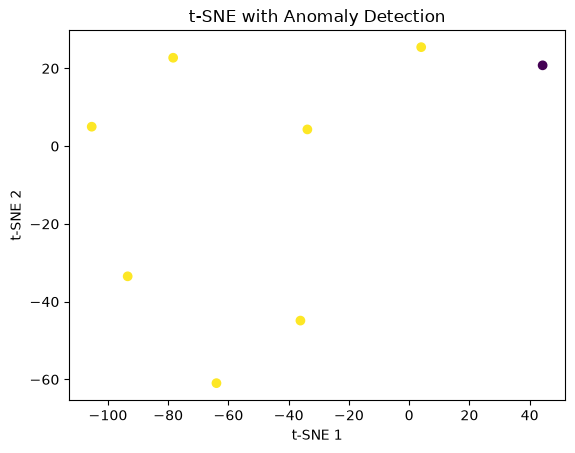

Number of anomalies: 1
Anomaly points: [[50 50]]


In [ ]:
# Practical Task Example 

from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ---------------------------------------
# 1. Prepare the data
# ---------------------------------------

# Scale the features before visualization.
X_scaled = StandardScaler().fit_transform(X)


# ---------------------------------------
# 2. Apply t-SNE
# ---------------------------------------

# Reduce the dataset to 2 dimensions for visualization.
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=3,
)

X_tsne = tsne.fit_transform(X_scaled)


# ---------------------------------------
# 3. Detect anomalies
# ---------------------------------------

# Find unusual points using Isolation Forest.
model = IsolationForest(
    contamination=0.10,
    random_state=42
)

predictions = model.fit_predict(X_scaled)


# ---------------------------------------
# 4. Visualize the result
# ---------------------------------------

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=predictions
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE with Anomaly Detection")

plt.show()


# ---------------------------------------
# 5. Count the detected anomalies
# ---------------------------------------

number_of_anomalies = sum(predictions == -1)

print("Number of anomalies:", number_of_anomalies)

# To get the actual anomaly points
anomalies = X[predictions == -1]
print("Anomaly points:", anomalies)